In [4]:
import pandas as pd

df = pd.read_csv("CarPrice_Assignment.csv")

print(df.columns)

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='str')


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [6]:
#Load dataset
df = pd.read_csv("CarPrice_Assignment.csv")

print(df.head())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [7]:
#Dataset information
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

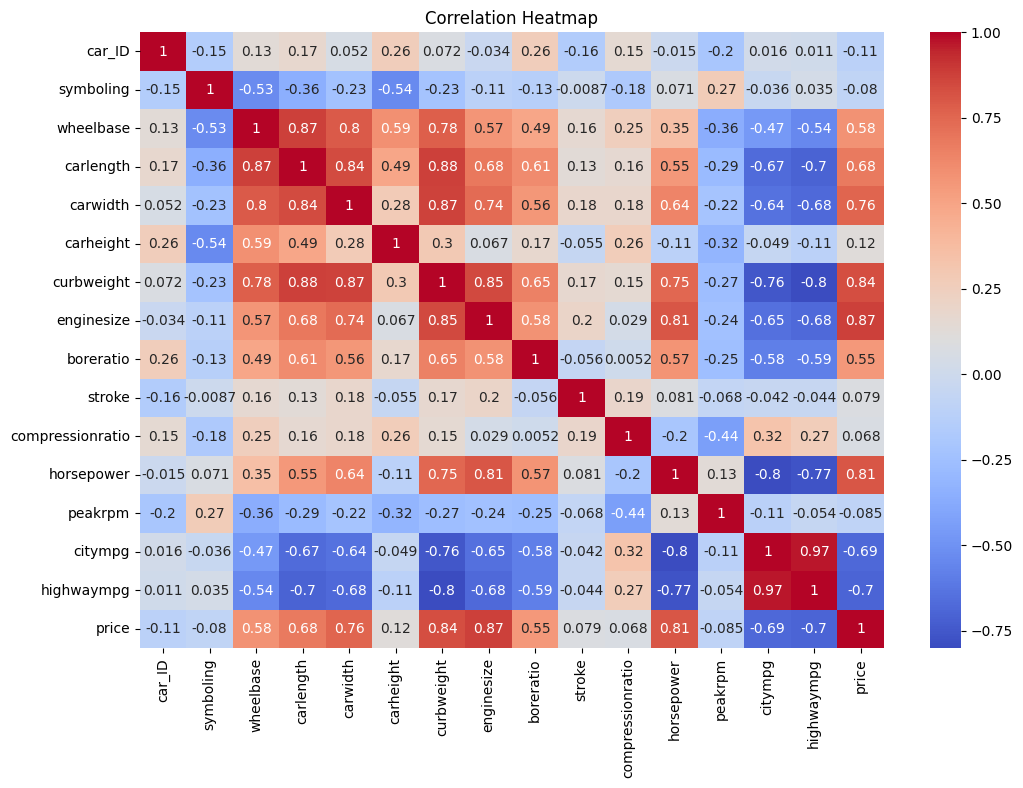

In [8]:
# corelation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

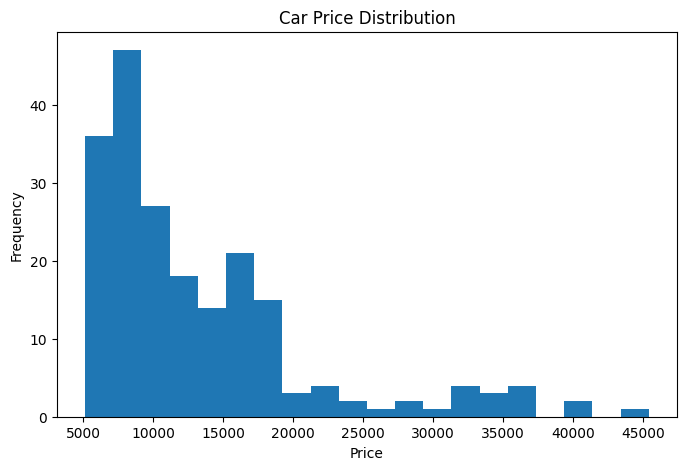

In [9]:
#Price Distribution
plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=20)

plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

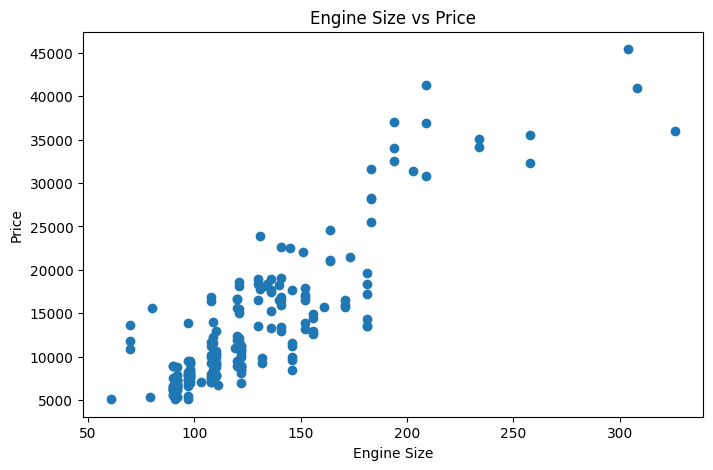

In [13]:
 #Engine Size vs Price
plt.figure(figsize=(8,5))

plt.scatter(
    df['enginesize'],
    df['price']
)

plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.title("Engine Size vs Price")

plt.show()

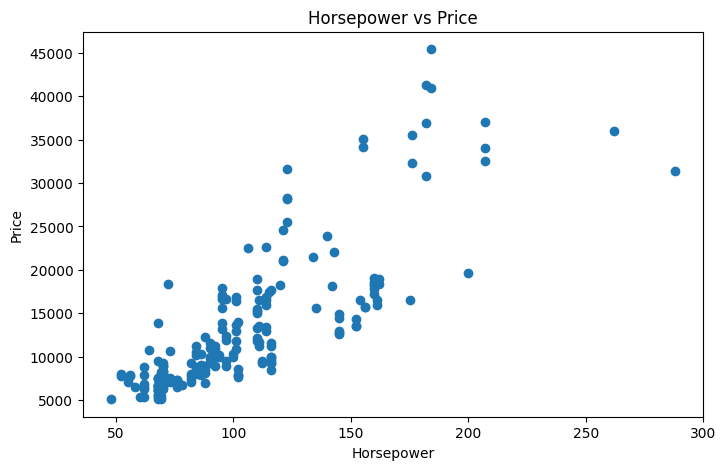

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['horsepower'],
    df['price']
)

plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Horsepower vs Price")

plt.show()

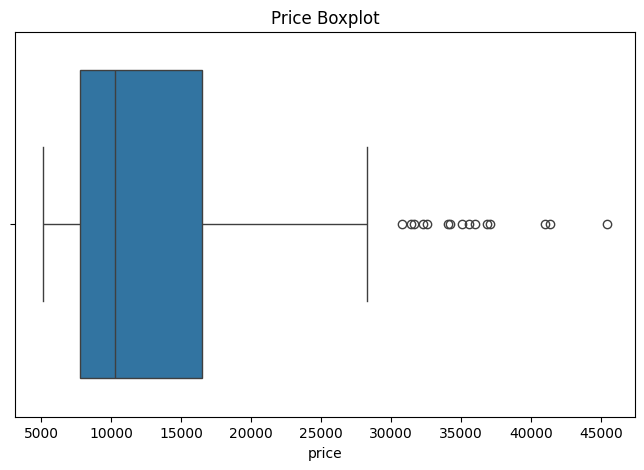

In [ ]:
#Horsepower vs Price
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title("Price Boxplot")

plt.show()

In [16]:
#Features and Target
X = df[[
    'horsepower',
    'enginesize',
    'curbweight',
    'citympg',
    'highwaympg'
]]

y = df['price']

In [ ]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Train Model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
#Predictions
y_pred = model.predict(X_test)

In [20]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance)

      Feature  Coefficient
0  horsepower    47.481731
1  enginesize    80.713219
2  curbweight     4.082621
3     citympg  -114.188137
4  highwaympg    69.240732


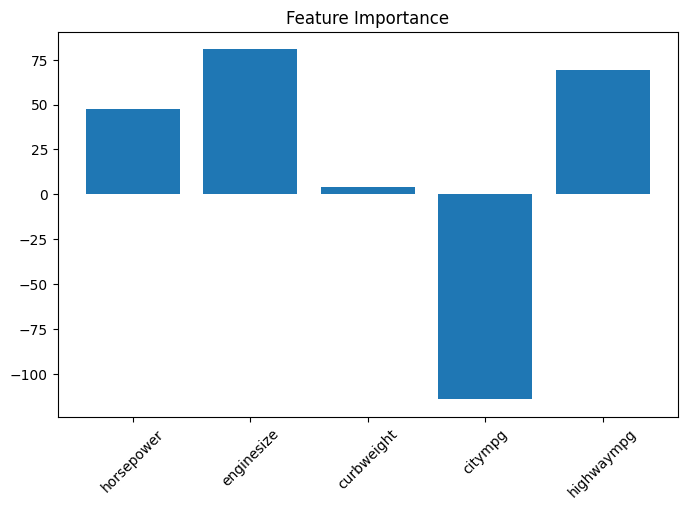

In [21]:
#Feature Importance Graph
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Coefficient']
)

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [23]:
#User Input Prediction
horsepower = int(input("Enter Horsepower: "))
enginesize = int(input("Enter Engine Size: "))
curbweight = int(input("Enter Curb Weight: "))
citympg = int(input("Enter City MPG: "))
highwaympg = int(input("Enter Highway MPG: "))

car = pd.DataFrame({
    'horsepower':[horsepower],
    'enginesize':[enginesize],
    'curbweight':[curbweight],
    'citympg':[citympg],
    'highwaympg':[highwaympg]
})

prediction = model.predict(car)

print(
    "\nPredicted Car Price =",
    round(prediction[0],2)
)


Predicted Car Price = 12540.02
